In [1]:
import pandas as pd
import numpy as np
from datetime import time
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

import torch
import torch.nn as nn

from ortools.constraint_solver import pywrapcp, routing_enums_pb2

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"], format="%H:%M:%S", errors="coerce").dt.time
df.dropna(inplace=True)
cleaned_df = df[
    (df["Delivery_location_latitude"] != 0.0) &
    (df["Delivery_location_longitude"] != 0.0) &
    (df["Restaurant_latitude"] != 0.0) &
    (df["Restaurant_longitude"] != 0.0) 
]
cleaned_df["Type_of_vehicle"] = df["Type_of_vehicle"].str.strip()
main_df = cleaned_df[cleaned_df["Type_of_vehicle"].isin(["motorcycle", "scooter"])]

C:\Users\upeks\AppData\Local\Temp\ipykernel_19064\3404397470.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order_Date"] = pd.to_datetime(df["Order_Date"])
C:\Users\upeks\AppData\Local\Temp\ipykernel_19064\3404397470.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df["Type_of_vehicle"] = df["Type_of_vehicle"].str.strip()


In [4]:
temp_df = main_df[["Restaurant_latitude", "Restaurant_longitude"]]
temp_df = temp_df.groupby(by=["Restaurant_latitude", "Restaurant_longitude"]).size().reset_index(name="Count")
temp_df.sort_values(by="Count", inplace=True, ascending=False)
temp_df = temp_df[
    (temp_df["Restaurant_latitude"] >= 20.0) &
    (temp_df["Restaurant_latitude"] <= 24.0) &
    (temp_df["Restaurant_longitude"] >= 74.0) &
    (temp_df["Restaurant_longitude"] <= 78.0) 
]

In [5]:
main_df = main_df[
    (main_df["Restaurant_latitude"].isin(temp_df["Restaurant_latitude"])) &
    (main_df["Restaurant_longitude"].isin(temp_df["Restaurant_longitude"]))
]

In [6]:
start_time = time(0, 1)
end_time = time(23, 59)
main_restaurant_latitude = main_df["Restaurant_latitude"].to_numpy().mean()
main_restaurant_longitude = main_df["Restaurant_longitude"].to_numpy().mean()
full_date_range = pd.date_range(start="2022-03-01", end="2022-04-06")

In [7]:
time_df = main_df[main_df["Time_Orderd"].apply(lambda x: start_time <= x <= end_time)]

In [8]:
scaler1 = StandardScaler()
time_df[["Customer_Latitude_Scaled", "Customer_Longitude_Scaled"]] = scaler1.fit_transform(time_df[["Delivery_location_latitude", "Delivery_location_longitude"]])

C:\Users\upeks\AppData\Local\Temp\ipykernel_19064\3128728941.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_df[["Customer_Latitude_Scaled", "Customer_Longitude_Scaled"]] = scaler1.fit_transform(time_df[["Delivery_location_latitude", "Delivery_location_longitude"]])
C:\Users\upeks\AppData\Local\Temp\ipykernel_19064\3128728941.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_df[["Customer_Latitude_Scaled", "Customer_Longitude_Scaled"]] = scaler1.fit_transform(time_df[["Delivery_location_lati

In [9]:
def elbow_method(data, max_k):
    means = []
    inertias = []
    for k1 in range(1, max_k+1):
        kmeans_elbow = KMeans(n_clusters=k1)
        kmeans_elbow.fit(data)
        means.append(k1)
        inertias.append(kmeans_elbow.inertia_)

    plt.plot(means, inertias, "o-")
    plt.xlabel("K-Means")
    plt.ylabel("Inertias")
    plt.grid(True)
    plt.show()

c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  

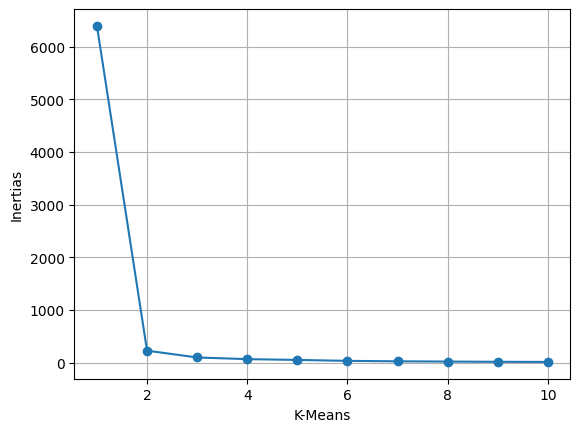

In [10]:
elbow_method(time_df[["Customer_Latitude_Scaled", "Customer_Longitude_Scaled"]], 10)

In [11]:
kmeans_optmial = KMeans(n_clusters=2)
kmeans_optmial.fit(time_df[["Customer_Latitude_Scaled", "Customer_Longitude_Scaled"]])
time_df["K-Means"] = kmeans_optmial.labels_

C:\Users\upeks\AppData\Local\Temp\ipykernel_19064\3964334666.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_df["K-Means"] = kmeans_optmial.labels_


In [12]:
cluster_df = time_df[time_df["K-Means"] == 0]
lstm_df = cluster_df.groupby("Order_Date").size().reset_index(name="Number of Orders")
lstm_df.sort_values(by="Order_Date", inplace=True)
lstm_df.set_index("Order_Date", inplace=True)
lstm_df = lstm_df.reindex(full_date_range, fill_value=0)
lstm_df.reset_index(inplace=True)
lstm_df.columns = ["Order_Date", "Number of Orders"]

In [13]:
lstm_df

,Order_Date,Number of Orders
0,2022-03-01,92
1,2022-03-02,71
2,2022-03-03,88
3,2022-03-04,76
4,2022-03-05,84
5,2022-03-06,77
6,2022-03-07,88
7,2022-03-08,67
8,2022-03-09,82
9,2022-03-10,72


In [14]:
data = lstm_df["Number of Orders"].to_numpy()
data = data.reshape(-1, 1)

In [16]:
def create_sequences(data, sequence_length):
    sequences = []
    for i in range(len(data)-sequence_length):
        seq = data[i:i+sequence_length]
        lbl = data[i+sequence_length]
        sequences.append((seq, lbl))
    return sequences

In [17]:
sequences = create_sequences(data, 5)

In [18]:
X = np.array([seq[0] for seq in sequences])
y = np.array([lbl[1] for lbl in sequences])

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [21]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        output = self.fc(out[:, -1, :])
        return output

In [22]:
model = LSTMModel(1, 4, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
epochs = 100

In [ ]:
for epoch in range(epochs):
    model.train()
    output = model(X_train)
    loss = criterion(output, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch: {epoch+1} Loss: {loss.item()}")

In [ ]:
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    loss = criterion(predictions, y_test)
    print(f"Test Loss: {loss.item()}")

In [ ]:
plt.plot(predictions.numpy(), label="Predicted Values", marker="o")
plt.plot(y_test.numpy(), label="Actual Values", marker="x")
plt.legend()
plt.show()

In [26]:
predictions_org = scaler2.inverse_transform(predictions.numpy())
y_test_org = scaler2.inverse_transform(y_test.numpy())

In [ ]:
plt.plot(predictions_org, label="Predicted Values", marker="o")
plt.plot(y_test_org, label="Actual Values", marker="x")
plt.legend()
plt.show()